# Abstract

The purpose of this notebook is to review some code to be used to analyze the Australian National University (ANU) Case Study. This case is described in the book [Constructing Insurable Risk Portfolios](https://users.ssc.wisc.edu/~ewfrees/InsurableRisks/).

In particular, it is introduced in Section 1.2, further described in Section 6.3.2, with porfolios develope in Chapter 7 and Section 8.2.

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/ANUCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>





#  Getting Started - Reminder

Start by going to "Runtime", select "Change Runtime Type", ensure that "R" is selected, and click "Save".

Next, run the following two boxes. The first checks that we can do basic calculations. The second is an "R" command (generate 10 standard normal random variates), to make sure that "R" is working. Then, try changing the numbers so you can convince yourself that this is an interactive environment.

You can make changes to a Colab notebook, and they will persist for as long as you keep your browser tab open. But once you close it, the changes will be lost. To avoid this, make sure you save a copy of the notebook to your Google Drive by selecting File → “Save a copy in Drive”.

## Load Libraries

As is the custom with Jupyter notebooks, we start by loading some libraries that are going to be helpful. In the following code, we also indicate where the libraries are needed with comments.

In [ ]:
install.packages(c("tweedie"))
library(tweedie)
install.packages("alabama")
library(alabama)
library(ggplot2)
install.packages("gridExtra")
library(gridExtra)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



#  Overview of the Data

## Recreate Tables from Chapters 6 and 8

Generate the Table 6.1: **ANU Insurance Premiums, 2020-2021** to get a feel for the data input.



In [ ]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/ANUData/ANURiskParameters.csv", destfile = "ANURiskParameters.csv")
Table61 <- read.csv(file = "ANURiskParameters.csv")
str(Table61)
Table61

'data.frame':	15 obs. of  7 variables:
 $ Class.of.Insurance: chr  "Property" "General and Products Liability" "Cyber" "Crime" ...
 $ Class             : chr  "Property" "Gen Prod Liab" "Cyber" "Crime" ...
 $ Insurer           : chr  "London and Others                     " "" "London" "AIG" ...
 $ Limit             : chr  "1,000,000,000" "" "2,000,000" "20,000,000" ...
 $ Deductible        : chr  "5,000,000" "" "250,000" "100,000" ...
 $ Premium           : int  28564759 448500 75721 100000 84000 11676 104920 75000 100000 20000 ...
 $ ExpNum            : num  0.67 0.5 0.25 0.25 0.25 0.25 10 200 0.25 0.25 ...


Class.of.Insurance,Class,Insurer,Limit,Deductible,Premium,ExpNum
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
Property,Property,London and Others,"1,000,000,000","5,000,000",28564759,0.67
General and Products Liability,Gen Prod Liab,,,,448500,0.50
Cyber,Cyber,London,"2,000,000","250,000",75721,0.25
Crime,Crime,AIG,"20,000,000","100,000",100000,0.25
Employment Practices Liability,Employ P Liab,AIG,"2,000,000","100,000",84000,0.25
Expat,Expat,Chubb,,,11676,0.25
Group Personal Accident,Group Pers Acc,Chubb,As per schedule,Various,104920,10.00
Corporate Travel,Corp Travel,Chubb,As per schedule,Various,75000,200.00
Professional Indemnity,Prof Indemnity,Newline,$20m / $40m,"100,000",100000,0.25


Generate the Table 8.1 **ANU Summary Statistics** to get a feel for the data input.

In [ ]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/ANUData/ANURiskParametersInput.csv", destfile = "ANURiskParametersInput.csv")
RiskParameters <- read.csv(file = "ANURiskParametersInput.csv",header=T)

#  ANURiskDistn
#  Bring in Risk Parameters

#RiskParameters<- read.csv("../Data/ANURiskParametersInput.csv",header=T)

riskTypes <- RiskParameters$Class.of.Insurance
riskTypesShort <- RiskParameters$Class

ANU.lambda <- RiskParameters$ExpNum
ANU.Prem   <- RiskParameters$Premium / 1000  #thousands of AUD
ANU.mu     <- rep(NA,length(ANU.lambda))
ANU.deduct <- RiskParameters$Deductible / 1000  #thousands of AUD
ANU.deduct1 <- ANU.deduct
ANU.deduct1[ANU.deduct1<1] <-1
ANU.deduct10 <- ANU.deduct
ANU.deduct10[ANU.deduct10<10] <-10
power      <- 1.67
power.vec <- c(1.9, 1.9, rep(1.67,13))

TweedieClaims <- c(1:6, 9:12, 14, 15)
NotTweedieClaims <- c(7, 8, 13)

for (jPrem in TweedieClaims){

  Delta.Prem <- function(mu.fct){
         power <- power.vec[jPrem]
         phi.fct = mu.fct**(2-power)/(ANU.lambda[jPrem]*(2-power))
         sfF <- function(x){1-tweedie::ptweedie(x, power=power,
                                                mu=mu.fct, phi=phi.fct)}
         prem <- mu.fct - integrate(sfF, lower = 0,
                                    upper = ANU.deduct[jPrem])$value
         return(ANU.Prem[jPrem] - prem)}
    ANU.mu[jPrem] <- uniroot(Delta.Prem, lower = 2, upper = 4000000)$root
}

ANU.phi <- ANU.mu**(2-power.vec)/(ANU.lambda*(2-power.vec))
ANU.stdDev <- sqrt(ANU.phi)*ANU.mu**(power.vec/2)

# For GPA (jLine=7), Travel (jLine=8), and Motor Vehicle(jLine=13),
           #use Lognormal Distribution
#Group Personal Accident
ANU.lambda[7] = 20
paramGPA1     = 6.982327314 - log(1000)
paramGPA2     = 0.103236644
ANU.mu[7]     = ANU.lambda[7]*exp(paramGPA1 + paramGPA2/2)
ANU.stdDev[7] = ANU.mu[7]*sqrt( exp(paramGPA2)-1 )
#Travel
ANU.lambda[8] = 220
paramTrv1     = 6.3487941  - log(1000)
paramTrv2     = 0.220671512
ANU.mu[8]     = ANU.lambda[8]*exp(paramTrv1 + paramTrv2/2)
ANU.stdDev[8] = ANU.mu[8]*sqrt( exp(paramTrv2)-1 )
# Motor Vehicle
ANU.lambda[13]= 80
paramMV1     = 7.937941050 - log(1000)
paramMV2     = 0.414643912
ANU.mu[13]    = ANU.lambda[13]*exp(paramMV1 + paramMV2/2)
ANU.stdDev[13]= ANU.mu[13]*sqrt( exp(paramMV2)-1 )

ANU.quan95 <- 0*ANU.mu -> ANU.quan99
for (jPrem in TweedieClaims){
  ANU.quan95[jPrem] <-
    tweedie::qtweedie(p=0.95, power=power.vec[jPrem],
                    mu=ANU.mu[jPrem], phi=ANU.phi[jPrem])
  ANU.quan99[jPrem] <-
    tweedie::qtweedie(p=0.99, power=power.vec[jPrem],
                    mu=ANU.mu[jPrem], phi=ANU.phi[jPrem])
}
ANU.quan95[NotTweedieClaims] <-
    ANU.mu[NotTweedieClaims] +
       qnorm(.95)*ANU.stdDev[NotTweedieClaims]
ANU.quan99[NotTweedieClaims] <-
    ANU.mu[NotTweedieClaims] +
       qnorm(.99)*ANU.stdDev[NotTweedieClaims]
#  Quantiles for Individuals Claims
Ind.ANU.quan99 <- ANU.quan99
Ind.ANU.quan99[7] <- exp( paramGPA1 + qnorm(.99)*sqrt(paramGPA2) )
Ind.ANU.quan99[8] <- exp( paramTrv1 + qnorm(.99)*sqrt(paramTrv2) )
Ind.ANU.quan99[13] <- exp( paramMV1 + qnorm(.99)*sqrt(paramMV2) )

#save(ANU.deduct, ANU.Prem, ANU.lambda, ANU.mu,  ANU.stdDev, ANU.quan95,
 #    ANU.quan99, Ind.ANU.quan99, riskTypes, riskTypesShort, ANU.phi,
  #   file = "../ChapTablesData/Chap7/PremTable.Rdata")

In [ ]:

Param.mat <- cbind(ANU.deduct, ANU.Prem, ANU.lambda, ANU.mu,
                   ANU.stdDev, ANU.quan95, ANU.quan99 )
Param.mat <- round(Param.mat, digits = 0)
Param.mat[,3] <- ANU.lambda
row.names(Param.mat) <- riskTypes
colnames(Param.mat) <- c("Deductible", "Premium", "Expected Number",
  "Mean",   "Standard Dev", "95th Percentile", "99th Percentile")
print('ANU Risk Summary Statistics')
Param.mat


[1] "ANU Risk Summary Statistics"


,Deductible,Premium,Expected Number,Mean,Standard Dev,95th Percentile,99th Percentile
Property,5000,23565,0.67,24753,95631,147455,481482
General and Products Liability,100,448,0.50,467,2090,2585,10354
Cyber,250,76,0.25,112,389,748,1992
Crime,100,100,0.25,117,408,785,2090
Employment Practices Liability,100,84,0.25,101,351,675,1799
Expatriate,0,12,0.25,12,41,78,208
Group Personal Accident,0,105,20.00,23,7,35,40
Corporate Travel,0,75,220.00,140,70,255,303
Professional Indemnity,100,100,0.25,117,408,785,2090
Medical Malpractice,100,20,0.25,33,116,223,594


## Simulate Multivariate Data

From these marginal distributions and assumptions about the dependencies, one can simulate the multivariate data.

Section 8.3.6 Appendix. Generate ANU Simulated Distributions, describes how to generate predictive distributions. This code takes longer and so we will skip it now but just pull in results from the code.



In [ ]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/ANUData/AggClaimsMay100Kw0.7.Rdata", destfile = "AggClaimsMay100Kw0.7.Rdata")
load(file = "AggClaimsMay100Kw0.7.Rdata")


Just to make sure that data was read in properly, let's look at the structure and do a summary.

In [ ]:
ls.str() # List objects with details
summary(Claims)

alpha :  num 0.8
ANU.deduct :  num [1:15] 5000 100 250 100 100 0 0 0 100 100 ...
ANU.deduct1 :  num [1:15] 5000 100 250 100 100 1 1 1 100 100 ...
ANU.deduct10 :  num [1:15] 5000 100 250 100 100 10 10 10 100 100 ...
ANU.lambda :  num [1:15] 0.67 0.5 0.25 0.25 0.25 0.25 20 220 0.25 0.25 ...
ANU.mu :  num [1:15] 24753 467 112 117 101 ...
ANU.phi :  num [1:15] 41 37 57.5 58.4 55.6 ...
ANU.Prem :  num [1:15] 23564.8 448.5 75.7 100 84 ...
ANU.quan95 :  num [1:15] 147455 2585 748 785 675 ...
ANU.quan99 :  num [1:15] 481482 10354 1992 2090 1799 ...
ANU.stdDev :  num [1:15] 95631 2090 389 408 351 ...
ANURTCmax :  num 733
ANURTCmax.vec :  num [1:11] 1127 1067 949 830 712 ...
bw :  num 1
Claims :  num [1:100000, 1:15] 0 0 41365.14 7.18 0 ...
CstLevNum :  num [1:11] 0.95 0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1 ...
Delta.Prem : function (mu.fct)  
dfPlot : 'data.frame':	11 obs. of  22 variables:
 $ RTCmax  : num  1127 1067 949 830 712 ...
 $ RTC     : num  1127 1067 948 825 708 ...
 $ VaR     : num  62

       V1                V2                V3               V4        
 Min.   :      0   Min.   :    0.0   Min.   :   0.0   Min.   :   0.0  
 1st Qu.:      0   1st Qu.:    0.0   1st Qu.:   0.0   1st Qu.:   0.0  
 Median :      0   Median :    0.0   Median :   0.0   Median :   0.0  
 Mean   :  24544   Mean   :  463.0   Mean   : 113.5   Mean   : 117.8  
 3rd Qu.:   1296   3rd Qu.:    2.3   3rd Qu.:   0.0   3rd Qu.:   0.0  
 Max.   :3543739   Max.   :55365.8   Max.   :7891.4   Max.   :8764.4  
       V5             V6               V7               V8        
 Min.   :   0   Min.   :  0.00   Min.   : 4.577   Min.   : 96.71  
 1st Qu.:   0   1st Qu.:  0.00   1st Qu.:18.950   1st Qu.:133.32  
 Median :   0   Median :  0.00   Median :22.444   Median :140.36  
 Mean   : 100   Mean   : 11.49   Mean   :22.687   Mean   :140.52  
 3rd Qu.:   0   3rd Qu.:  0.00   3rd Qu.:26.151   3rd Qu.:147.56  
 Max.   :7060   Max.   :752.30   Max.   :47.209   Max.   :188.32  
       V9            V10          

## General Constrained Optimization Approach


As before, we will use the `auglag` function for general constrained optimization. It requires:

*   An objective function (`fn`) to minimize.
    *   Optionally, a gradient function for `fn` (`gr`).
*   An inequality constraint function (`hin`) where `hin(x) >= 0`.
    *   Optionally, a gradient function for `hin` (`jac_hin`).

Our problem is:

*   **Minimize**: $RM[g({\bf X}; \boldsymbol \theta)]$ (uncertainty of retained risks)
*   **Subject to**: $RTC(\boldsymbol \theta) \le RTC_{max}$ (budget constraint)
*   **Subject to**: $\theta_j \ge 0 $ for all $j$ (non-negative weights)

Note that you need to provide starting values for this approach...

# ANU Optimization

## Useful Functions

Here are some useful functions for the optimization

*  starting with a function `RetClaims.fct` for retained claims $g({\bf X}; \boldsymbol \theta)$
*  then, `ESKernmin.fct` computes a smoothed version of the expected shortfall objective function, described in Section 7.3,
*  `RTCR.fct` is a function to compute the risk transfer cost (based on simulation)
*  `ESSummary.fct` is a function to summarize risk measures
*  `f0z.fct` provides the gradient of the smoothed expected shortfall objective function
*  `ThetaOptim.fct` computes the frontier


In [ ]:
#install.packages("alabama")
#library(alabama)

# These functions are for ES minimization of
#  Excess of Loss (TRUE) and Quota Share (ExLoss = FALSE)

# Function to Compute Retained Claims
RetClaims.fct <- function(coeff, Xsim, ExLoss = TRUE){
  VaR.z0    <- coeff[1]
  theta.vec <- coeff[-1]
  p.num     <- length(theta.vec)
  RetClaims <- rep(0, nrow(Xsim) )
  if (ExLoss){  # Excess of Loss
     for (kidx in 1:p.num){RetClaims <- RetClaims +
                             pmin(Xsim[,kidx], theta.vec[kidx]) }
     } else {  # Quota Share
            RetClaims  <- as.vector(Xsim %*% theta.vec)   }
  return( RetClaims )
}  # end RetClaims.fct function

#  ESKernmin.fct evaluates the ES objective function
#    using kernel smoothing
ESKernmin.fct <- function(coeff, RetClaims){
  VaR.z0        <- coeff[1]
  theta.vec     <- coeff[-1]
  ESKern1.fct   <- function(ytidle) { as.numeric( mean(
                        pmax(RetClaims + bw * ytidle - VaR.z0, 0) ) ) *
                               dnorm(ytidle)  }
  ESKernmin     <- VaR.z0 + integrate(Vectorize(ESKern1.fct),
                                      lower = -6, upper = 6)$value / (1-alpha)
  return( ESKernmin )
}  # end ESKernmin.fct function

#Function to Compute Simulated RTC
RTCR.fct <- function(Xsim, RetClaims){
  CeededClaims <- rowSums(Xsim) - RetClaims
  RTC.R     <- mean( CeededClaims )
  return( RTC.R )
}  # end RTCR.fct function

# Function to Summarize Risk Measures
ESSummary.fct <- function(coeff, RetClaims){
  VaR.z0    <- coeff[1]
  theta.vec <- coeff[-1]
  ones      <- rep(1, length(RetClaims) )
  stddev    <- sd(RetClaims)
  VaR       <- as.numeric(quantile(RetClaims, prob = alpha, na.rm = TRUE))
  Kern.df   <- function(y){ yarg <- (y*ones - RetClaims)/bw
                            return(mean(pnorm(yarg)) - alpha)}
  Kern.VaR  <- uniroot(f=Kern.df,lower = VaR - 100, upper = VaR + 100)$root
  ESmin     <- as.numeric(VaR.z0 +
                            mean(pmax(RetClaims - VaR.z0, 0)) /(1-alpha) )
  ES        <- as.numeric(VaR   +
                            mean(pmax(RetClaims - VaR,   0)) /(1-alpha) )
  ESKern1.fct <- function(y) { as.numeric ( mean( pmax(
                           RetClaims -  VaR.z0 +  bw * y, 0) ) ) * dnorm(y) }
  ESKernmin   <- VaR.z0 + integrate(Vectorize(ESKern1.fct),
                                   lower = -6, upper = 6)$value / (1-alpha)
  ESKern2.fct <- function(y) { as.numeric ( mean( pmax(
                           RetClaims - Kern.VaR + bw * y, 0) ) ) * dnorm(y) }
  ESKern      <- Kern.VaR + integrate(Vectorize(ESKern2.fct), lower = -6,
                                     upper = 6)$value / (1-alpha)
  return( c(VaR, Kern.VaR, ESmin, ES,  ESKernmin, ESKern, stddev) )
}  # end ESSummary.fct function

# Gradient of the ES Objective Function
f0z.fct <- function(coeff, Xsim, RetClaims, ExLoss = TRUE){
  VaR.z0        <- coeff[1]
  theta.vec     <- coeff[-1]
  numLoss       <- nrow(Xsim)
  ones          <- rep(1, numLoss )
  VaR.z0arg     <- (VaR.z0*ones - RetClaims) / bw
  partial.z0    <- 1 - mean( 1-pnorm(VaR.z0arg) ) / (1 - alpha)

  if (ExLoss){  # Excess of Loss
              mat.check <-  t( 1* ( t(Xsim) > theta.vec) )
      } else {  # Quota Share
              mat.check <- Xsim  }
  temp          <- ( 1-pnorm(VaR.z0arg) ) %*% mat.check / numLoss
  partial.theta <- temp / (1 - alpha)
  return( c(partial.z0, partial.theta) )
  }  # end f0z.fct function

# Function to Construct a Frontier of Optimal Portfolios
#  p.z is the number of coefficients (including VaR)
ThetaOptim.fct <- function(Xsim, ExLoss = TRUE, p.z = 15,
                           RTCmax.vec, starter.coeff) {
  Output.mat <- matrix(0,nrow = length(RTCmax.vec), ncol = 1+6+p.z)
  f0.ES      <- function(coeff){ RetClaims <-
                                 RetClaims.fct(coeff, Xsim, ExLoss)
                return(ESKernmin.fct(coeff, RetClaims) ) }
  f0.grad    <- function(coeff){ RetClaims <-
                                 RetClaims.fct(coeff, Xsim, ExLoss)
                return(f0z.fct(coeff, Xsim, RetClaims, ExLoss) ) }
  RTC.optim  <- function(coeff){ RetClaims <-
                                 RetClaims.fct(coeff, Xsim, ExLoss)
                                 return(RTCR.fct(Xsim,RetClaims) )}
  # Use RTCR.fct for empirical RTCs, RTC.fct for lognormal

  for (jCost in 1:length(RTCmax.vec)){    # Start jCost Loop
    hin.ES <- function(coeff) {h <- NA    # Constraints in alabama
      h[1] <- RTCmax.vec[jCost] - RTC.optim(coeff)
      for (j in 1:p.z){h[j+1] <- 1e6*coeff[j] }
      if (ExLoss==FALSE){                 # For Quota Share
        for (j in 2:p.z){h[j+p.z] <-  1e6 * (1.0 - coeff[j]) }
      }
      return(h)
      }
  if (jCost > 1 ){starter.coeff <- ES.opt$par*1.1}
    z.params <- rep(0, p.z); LME.EX <- 0
    tryCatch({
        ES.opt <- alabama::auglag( par=starter.coeff,
           fn  = f0.ES,         # objective function
           gr  = f0.grad,       # gradient objective function
           hin = hin.ES,        # constraints
           control.outer=list(method="nlminb",trace=FALSE) )
        z.params <- ES.opt$par
        LME.EX <- ES.opt$lambda[1] },
        error=function(err) {
        z.params <- starter.coeff
        LME.EX <- 0} )
    RetClaims <- RetClaims.fct(z.params, Xsim, ExLoss)
    RTCR      <- RTC.optim(z.params)
    output    <- c(RTCmax.vec[jCost], RTCR ,
                   ESSummary.fct(z.params, RetClaims)[-c(3,5)],
                   z.params[-1] , LME.EX)
    cat("Theory Results",output, "\n")
    Output.mat[jCost,] <- output
    }  # end jCost Loop
    return(Output.mat)
    }  # end ThetaOptim.fct function


## Single Run

Here is some code for a single run of the optimization.

In [ ]:
# Example76Eval
# Bring in ANU Claims Data
#load(file = "../Data/SimData/AggClaimsMay100Kw0.7.Rdata")
nsimEval   <- 500 # You can increase this to 100,000 later
Xsim       <- Claims[1:nsimEval,-1] # -1 in order to remove Property
TotCostANU <- mean (rowSums(Xsim))
ANURTCmax  <- TotCostANU * 0.5

#  A Few Key Parameters
alpha     <- 0.80  #  0.95
bw        <- 1

starter.coeff <- rep(10, 15)

Time1 <- Sys.time()
OutANU.ES <- ThetaOptim.fct(Xsim, ExLoss = TRUE, p.z = 15,
                               RTCmax.vec=ANURTCmax, starter.coeff)
Sys.time() - Time1
u.names <- paste("u",1:14, sep="")
colnames(OutANU.ES) <- c("RTCmax", "RTC", "VaR", "Kern.VaR", "ESmin",
                            "ES", "StdDev",  u.names ,"LME")
round(OutANU.ES, digits = 2)

Theory Results 733.3307 733.3307 912.1344 912.0551 1372.72 1372.728 436.8319 260.4806 301.1174 257.6659 320.8022 351.1518 72.65215 450.6155 300.3534 162.8831 493.5493 37.18717 1110.989 160.1037 201.5261 3.36783 


Time difference of 6.776409 secs

RTCmax,RTC,VaR,Kern.VaR,ESmin,ES,StdDev,u1,u2,u3,⋯,u6,u7,u8,u9,u10,u11,u12,u13,u14,LME
733.33,733.33,912.13,912.06,1372.72,1372.73,436.83,260.48,301.12,257.67,⋯,72.65,450.62,300.35,162.88,493.55,37.19,1110.99,160.1,201.53,3.37


## Frontier

Here is some code for multiple runs of the optimization to create a frontier.

In [ ]:

# Example76Eval
# Bring in ANU Claims Data
#load(file = "../Data/SimData/AggClaimsMay100Kw0.7.Rdata")
nsimEval <- 100 # You can increase this to 100,000 later
Xsim    <- Claims[1:nsimEval,-1] # -1 in order to remove Property
TotCostANU <- mean (rowSums(Xsim))
CstLevNum <- 1 - c(0.05, seq(0.1, 0.9, length.out=9),0.95)
CstLevNum <- round(CstLevNum*100)/100
ANURTCmax.vec <- TotCostANU * CstLevNum

#  A Few Key Parameters
alpha     <- 0.80  #  0.95
bw        <- 1

starter.coeff <- rep(10, 15)

Time1 <- Sys.time()
OutMatANU.ES <- ThetaOptim.fct(Xsim, ExLoss = TRUE, p.z = 15,
                               RTCmax.vec=ANURTCmax.vec, starter.coeff)
Sys.time() - Time1   #58.55217 minutes for alpha = 0.95
                     #38.83844 for alpha = 0.80

u.names <- paste("u",1:14, sep="")
colnames(OutMatANU.ES) <- c("RTCmax", "RTC", "VaR", "Kern.VaR", "ESmin",
                            "ES", "StdDev",  u.names ,"LME")
round(OutMatANU.ES, digits = 2)

Theory Results 1126.746 1126.744 62.61744 62.82541 67.44798 67.57732 5.682245 1.535745e-05 2.999661 0.6925866 2.970988 1.847849e-11 18.35862 18.67569 1.116933 -3.048571e-13 4.60042 3.615603 18.67569 3.772416 5.215093 0 
Theory Results 1067.444 1067.441 120.4689 120.9179 123.035 123.345 3.590743 0.03229087 8.662268e-13 0.01625082 2.228919 4.33568e-10 20.27138 48.85064 0.08597549 0.2456479 2.431901 1.725869 48.85064 2.098155 1.862659 0 
Theory Results 948.8389 947.8008 243.1327 243.3135 249.8404 250.0013 8.477451 2.224881e-13 5.208892e-05 2.343919 4.947256 8.841567e-11 26.22103 105.6295 4.170698 1.286468e-13 7.275978 2.870433 105.6295 5.652714 5.17563 0 
Theory Results 830.2341 825.1533 368.2455 368.58 377.3843 377.5056 12.52636 0.01022963 4.018742e-09 2.576589e-09 6.858791 9.186616e-13 28.4642 135.023 5.332463 0.7564899 11.31835 2.289965 199.1373 5.253919 12.55106 0 
Theory Results 711.6292 707.9767 519.757 520.1405 567.5706 567.6265 65.56454 8.037664e-12 46.54543 33.31293 47.75758 7.42

Time difference of 49.1033 secs

RTCmax,RTC,VaR,Kern.VaR,ESmin,ES,StdDev,u1,u2,u3,⋯,u6,u7,u8,u9,u10,u11,u12,u13,u14,LME
1126.75,1126.74,62.62,62.83,67.45,67.58,5.68,0.00,3.00,0.69,⋯,18.36,18.68,1.12,0.00,4.60,3.62,18.68,3.77,5.22,0.00
1067.44,1067.44,120.47,120.92,123.03,123.34,3.59,0.03,0.00,0.02,⋯,20.27,48.85,0.09,0.25,2.43,1.73,48.85,2.10,1.86,0.00
948.84,947.80,243.13,243.31,249.84,250.00,8.48,0.00,0.00,2.34,⋯,26.22,105.63,4.17,0.00,7.28,2.87,105.63,5.65,5.18,0.00
830.23,825.15,368.25,368.58,377.38,377.51,12.53,0.01,0.00,0.00,⋯,28.46,135.02,5.33,0.76,11.32,2.29,199.14,5.25,12.55,0.00
711.63,707.98,519.76,520.14,567.57,567.63,65.56,0.00,46.55,33.31,⋯,33.05,156.76,25.41,0.00,48.34,27.32,317.93,18.80,74.99,0.00
593.02,590.09,736.31,736.71,881.45,881.46,202.88,6.71,308.58,199.53,⋯,36.35,172.44,225.80,0.00,189.19,37.98,374.47,90.98,157.77,0.00
474.42,474.42,1037.41,1037.49,1250.08,1250.12,339.03,50.41,597.16,442.61,⋯,39.99,189.68,594.39,189.00,299.11,76.27,411.92,191.45,229.60,3.46
355.81,355.81,1246.40,1246.39,1733.95,1734.01,555.46,762.94,807.55,795.74,⋯,43.99,208.65,806.47,297.50,433.91,134.62,453.11,210.60,647.16,4.34
237.21,237.21,1351.87,1352.41,2317.99,2317.99,812.38,1942.68,1431.91,1404.00,⋯,48.39,229.52,1570.65,513.68,477.30,148.09,498.42,231.66,711.87,5.00
118.60,118.60,1351.87,1352.41,2911.01,2911.01,1198.75,5812.06,1575.10,2861.70,⋯,53.22,252.47,4346.42,565.04,525.03,162.90,548.27,254.83,783.06,5.00


## Visualizing the Frontier

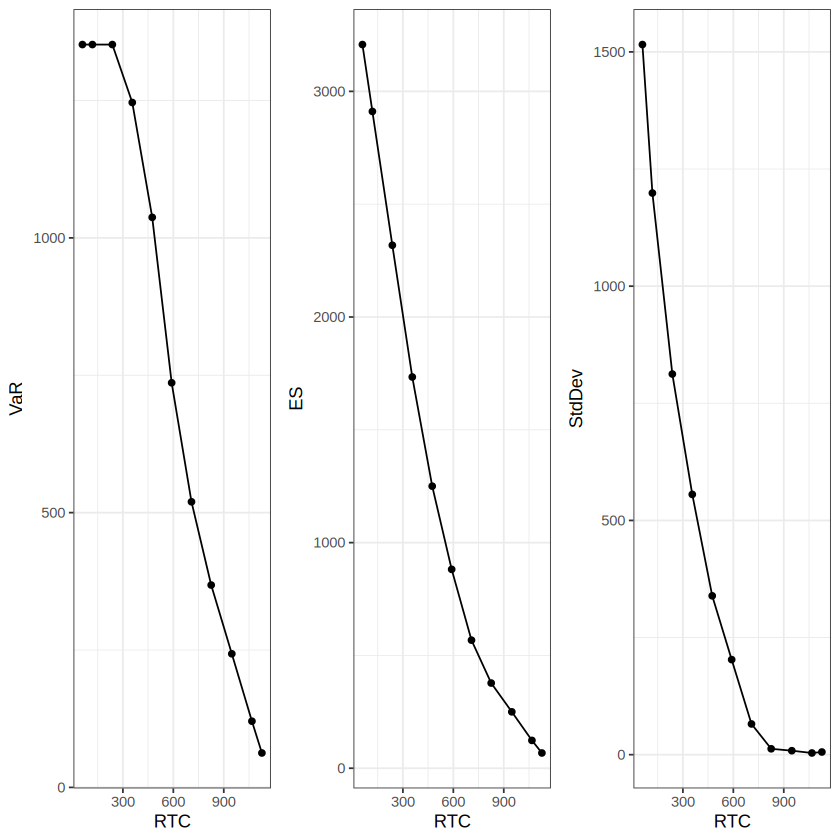

In [ ]:
#library(ggplot2)
#install.packages("gridExtra")
#library(gridExtra)
dfPlot <- data.frame(OutMatANU.ES)
p1 <- ggplot(dfPlot, aes(x=RTC, y=VaR)) + geom_point() + theme_bw() + geom_line()
p2 <- ggplot(dfPlot, aes(x=RTC, y=ES)) + geom_point() +
       theme_bw() + geom_line()  + labs(y = 'ES')
p3 <- ggplot(dfPlot, aes(x=RTC, y=StdDev)) + geom_point() + theme_bw() + geom_line()
grid.arrange(p1,p2,p3,nrow=1)

If you have time, you can check out Section 8.2 of the book for additional analyses.

# Appendix - Import and Describe the Data

After we have finished the workshop, you may wish to work with the basic data underlying these models. You can start by downloading the data from *Loss Data Analytics* site, https://openacttextdev.github.io/LDA_Ed2/DataResources.html


In [ ]:
download.file("https://datacommons.anu.edu.au/DataCommons/rest/records/anudc:6160/data/TravelClaims2022.csv", destfile = "TravelClaims2022.csv")
TravelClaims2022 <- read.csv(file = "TravelClaims2022.csv")
str(TravelClaims2022)

'data.frame':	2107 obs. of  8 variables:
 $ UW.Year            : int  2021 2021 2021 2021 2021 2021 2021 2021 2021 2021 ...
 $ Loss.Date          : chr  "19/12/2021" "9/4/2022" "2/5/2022" "5/5/2022" ...
 $ Reported.Date      : chr  "20/12/2021" "29/04/2022" "4/5/2022" "17/05/2022" ...
 $ Last.Trans.Date    : chr  "24/12/2021" "30/05/2022" "" "" ...
 $ Paid.Loss          : num  10000 423 0 0 1500 ...
 $ Outstanding.Reserve: num  0 0 500 562 0 ...
 $ Incurred.Loss      : num  10000 423 500 562 1500 ...
 $ Status             : chr  "Closed" "Closed" "Open" "Open" ...
